# Task 7: NLP Sentiment Classification Model

**Goal:** Clean a dataset of movie reviews, perform text tokenization and
bag-of-words encoding, and train a model to predict review sentiment
(positive / negative).

**Pipeline:** load data &rarr; validate &rarr; clean/tokenize text &rarr;
train/test split &rarr; bag-of-words encoding &rarr; train classifier &rarr;
evaluate &rarr; visualize.


In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

## 1. Configuration

All paths, filenames, and hyperparameters live here — nothing is hardcoded further down in the notebook.

In [2]:
# ---- Configuration ----
PROJECT_ROOT = Path.cwd()
VIS_DIR = PROJECT_ROOT / "visualizations"
VIS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 3000     # bag-of-words vocabulary cap
MIN_DF = 2               # ignore terms appearing in fewer than this many docs
NUM_SYNTHETIC_SAMPLES = 400   # only used if the NLTK corpus can't be downloaded
TOP_N_WORDS = 15         # top predictive words to plot per class

TEXT_COL = "review"
LABEL_COL = "sentiment"
CLEAN_COL = "clean_review"

CONFUSION_MATRIX_PATH = VIS_DIR / "confusion_matrix.png"
TOP_WORDS_PATH = VIS_DIR / "top_predictive_words.png"


## 2. Load Data

The dataset is the **NLTK `movie_reviews` corpus** — 2,000 real, human-labeled
movie reviews (balanced positive/negative), which is the standard benchmark
dataset for this exact task.

To avoid depending on a network download at run time (the internship's
established preference for avoiding path/download issues), `load_movie_reviews()`
attempts the NLTK download and **falls back to a programmatically generated,
balanced synthetic review dataset** if it's unavailable. Either way the notebook
runs end-to-end with no manual setup.

In [3]:
POSITIVE_WORDS = ["brilliant", "captivating", "heartwarming", "hilarious", "masterful",
                  "stunning", "gripping", "charming", "inspiring", "flawless",
                  "delightful", "outstanding", "touching", "clever", "unforgettable"]
NEGATIVE_WORDS = ["boring", "tedious", "cliched", "disappointing", "forgettable",
                  "dull", "awful", "mediocre", "predictable", "wooden",
                  "shallow", "overlong", "grating", "pointless", "lifeless"]
NEUTRAL_FILLERS = ["The plot follows a group of friends", "Set in a small town",
                   "The director's latest film", "This sequel", "The lead actor",
                   "The screenplay", "The cinematography", "The pacing",
                   "The soundtrack", "The ending"]

def build_synthetic_dataset(n, random_state=RANDOM_STATE):
    """Generate a balanced set of short template-based movie reviews."""
    rng = random.Random(random_state)
    reviews, labels = [], []
    for i in range(n):
        sentiment = "positive" if i % 2 == 0 else "negative"
        word_bank = POSITIVE_WORDS if sentiment == "positive" else NEGATIVE_WORDS
        filler = rng.choice(NEUTRAL_FILLERS)
        words = rng.sample(word_bank, k=3)
        review = (f"{filler} was {words[0]} and {words[1]}. "
                  f"Overall the film felt {words[2]} from start to finish.")
        reviews.append(review)
        labels.append(sentiment)
    out = pd.DataFrame({TEXT_COL: reviews, LABEL_COL: labels})
    return out.sample(frac=1, random_state=random_state).reset_index(drop=True)


In [4]:
def load_movie_reviews():
    """Load the NLTK movie_reviews corpus; fall back to a synthetic dataset
    if it cannot be downloaded (e.g. no internet access)."""
    try:
        import nltk
        nltk.download("movie_reviews", quiet=True)
        from nltk.corpus import movie_reviews
        fileids = movie_reviews.fileids()
        if not fileids:
            raise ValueError("Corpus downloaded but empty")
        reviews = [movie_reviews.raw(fid) for fid in fileids]
        labels = ["positive" if fid.startswith("pos") else "negative" for fid in fileids]
        out = pd.DataFrame({TEXT_COL: reviews, LABEL_COL: labels})
        source = "nltk_movie_reviews"
    except Exception as e:
        print(f"NLTK movie_reviews unavailable ({e}); using synthetic dataset instead.")
        out = build_synthetic_dataset(NUM_SYNTHETIC_SAMPLES)
        source = "synthetic"
    return out, source

df, data_source = load_movie_reviews()
print(f"Data source: {data_source}")
print(f"Shape: {df.shape}")
df.head()


Data source: nltk_movie_reviews
Shape: (2000, 2)


,review,sentiment
0,"plot : two teen couples go to a church party ,...",negative
1,the happy bastard's quick movie review \ndamn ...,negative
2,it is movies like these that make a jaded movi...,negative
3,""" quest for camelot "" is warner bros . ' firs...",negative
4,synopsis : a mentally unstable man undergoing ...,negative


## 3. Post-load Validation

In [5]:
assert df[TEXT_COL].isnull().sum() == 0, "Found null review text"
assert df[LABEL_COL].isnull().sum() == 0, "Found null labels"
assert set(df[LABEL_COL].unique()) == {"positive", "negative"}, "Unexpected label values"
assert (df[TEXT_COL].str.strip().str.len() > 0).all(), "Found empty review text"

print("Class balance:")
print(df[LABEL_COL].value_counts())
print("\nAll validation checks passed.")


Class balance:
sentiment
negative    1000
positive    1000
Name: count, dtype: int64

All validation checks passed.


## 4. Text Cleaning & Tokenization

Lowercase, strip punctuation/digits, tokenize on whitespace, and remove stopwords.

In [6]:
STOPWORDS = set("""a an the and or but if while is are was were be been being
this that these those to of in on at for with as by from it its it's i you
he she they we my your his her their our not no so very just can will would
""".split())

def clean_text(text):
    """Lowercase, strip non-letters, tokenize, remove stopwords/short tokens."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

df[CLEAN_COL] = df[TEXT_COL].apply(clean_text)
assert (df[CLEAN_COL].str.len() > 0).all(), "Cleaning produced empty text for some rows"
df[[TEXT_COL, CLEAN_COL]].head()


,review,clean_review
0,"plot : two teen couples go to a church party ,...",plot two teen couples go church party drink th...
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn bug got ...
2,it is movies like these that make a jaded movi...,movies like make jaded movie viewer thankful i...
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first feature length...
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...


## 5. Train/Test Split & Bag-of-Words Encoding

In [7]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df[CLEAN_COL], df[LABEL_COL],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df[LABEL_COL]
)

vectorizer = CountVectorizer(max_features=MAX_FEATURES, min_df=MIN_DF)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Vocabulary size: 3000
Train shape: (1600, 3000), Test shape: (400, 3000)


## 6. Model Training & Evaluation

A Multinomial Naive Bayes classifier is a standard, fast baseline for bag-of-words text classification.

In [8]:
def train_model(X_train, y_train):
    model = MultinomialNB()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds)
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    return preds, acc, report, cm

model = train_model(X_train, y_train)
preds, acc, report, cm = evaluate_model(model, X_test, y_test)

print(f"Accuracy: {acc:.4f}\n")
print(report)


Accuracy: 0.8175

              precision    recall  f1-score   support

    negative       0.81      0.83      0.82       200
    positive       0.83      0.81      0.82       200

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



## 7. Visualizations

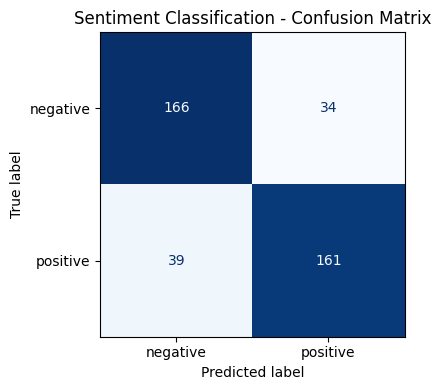

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Sentiment Classification - Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150)
plt.show()


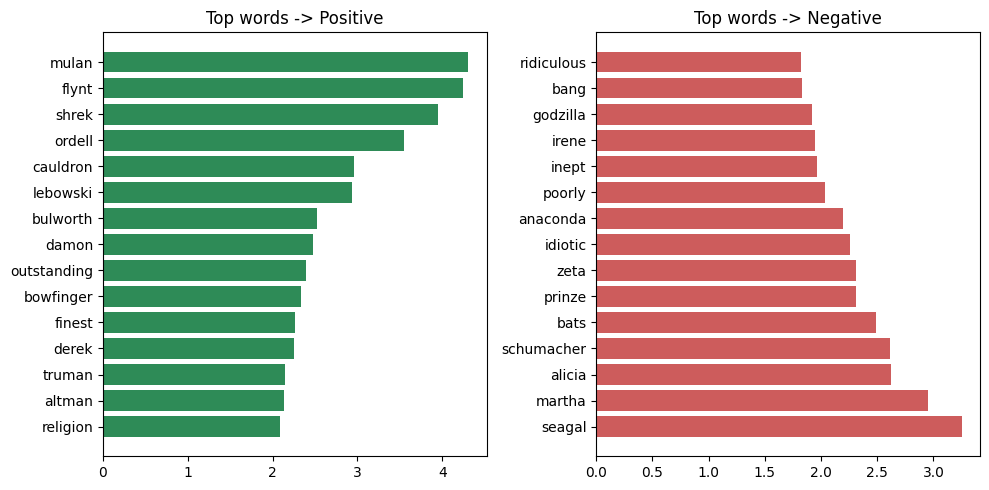

In [10]:
def plot_top_predictive_words(model, vectorizer, n=15, save_path=None):
    """Plot the words most strongly associated with each class, based on
    the difference in learned log-probabilities."""
    feature_names = np.array(vectorizer.get_feature_names_out())
    pos_idx = list(model.classes_).index("positive")
    neg_idx = list(model.classes_).index("negative")
    log_prob_diff = model.feature_log_prob_[pos_idx] - model.feature_log_prob_[neg_idx]

    top_pos = np.argsort(log_prob_diff)[-n:]
    top_neg = np.argsort(log_prob_diff)[:n]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].barh(feature_names[top_pos], log_prob_diff[top_pos], color="seagreen")
    axes[0].set_title("Top words -> Positive")
    axes[1].barh(feature_names[top_neg], -log_prob_diff[top_neg], color="indianred")
    axes[1].set_title("Top words -> Negative")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_top_predictive_words(model, vectorizer, n=TOP_N_WORDS, save_path=TOP_WORDS_PATH)


> **Note on the word plot:** with real movie reviews, the strongest predictive
> "words" are often proper nouns (actors, directors, franchise names) rather
> than pure sentiment terms — e.g. a beloved title skews positive, a
> panned one skews negative. This is expected behavior for bag-of-words on
> raw review text and reflects a real limitation of BoW: it captures word
> co-occurrence with a label, not sentiment meaning specifically.

## 8. Summary

In [11]:
print(f"Dataset source: {data_source}")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Test accuracy: {acc:.4f}")
print(f"Saved: {CONFUSION_MATRIX_PATH.name}, {TOP_WORDS_PATH.name}")


Dataset source: nltk_movie_reviews
Training samples: 1600, Test samples: 400
Vocabulary size: 3000
Test accuracy: 0.8175
Saved: confusion_matrix.png, top_predictive_words.png
